<a href="https://colab.research.google.com/github/carpotru08-cmd/Introducci-n_Ciencia_Datos_UdeM/blob/main/Intro_Ciencia_Datos/Estimaciones_puntuales_e_intervalos_de_confianza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis inferencial

El objetivo del análisis inferencial, bajo el enfoque clásico, es producir proposiciones probables acerca de los parámetros de una *población* a partir de los análisis de una *muestra*, partiendo del supuesto de que esta muestra representa fielmente a la población.

Los análisis de inferencia más importantes son:
- Estimaciones puntuales: estimaciones de valor esperado de un parámetro estadístico de la población, p.e., la media.
- Intervalos de confianza: estimaciones de los rangos de valores que mejor representan algún parámetro de interés.
- Aceptación o rechazo de una hipótesis.

Antes estas inferencias se hacian basadas en modelos teóricos ideales. Ahora, que los computadores se usan de manera masiva, se puede hacer inferencia basados en métodos más intensivos computacionalmente pero más realistas, como las técnicas de remuestreo, las cadenas de Markov, y los métodos de Monte Carlo.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_theme()

In [ ]:
df = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'],
    na_values=' ?'
)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Supongamos que queremos saber si, en general, las personas en Estados Unidos con ingreso superior a $\$50.000$ trabajan más que las personas con ingreso inferior a $\$50.000$.

Vamos a empezar haciendo un análisis descriptivo a nuestra muestra:

In [ ]:
df['hours-per-week'].describe()

,hours-per-week
count,32561.000000
mean,40.437456
std,12.347429
min,1.000000
25%,40.000000
50%,40.000000
75%,45.000000
max,99.000000


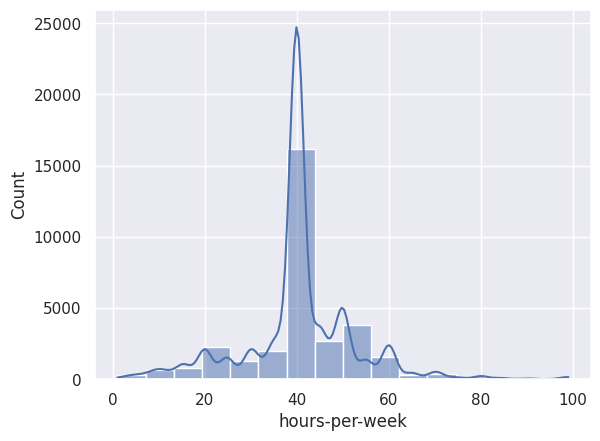

In [ ]:
sns.histplot(data=df, x='hours-per-week', kde=True, bins='sturges');

¿Qué observamos?

Ahora vamos a analizar esta variable agrupada por nivel de ingreso:

In [ ]:
df.groupby('income')['hours-per-week'].describe()

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,24720.0,38.840210,12.318995,1.0,35.0,40.0,40.0,99.0
>50K,7841.0,45.473026,11.012971,1.0,40.0,40.0,50.0,99.0


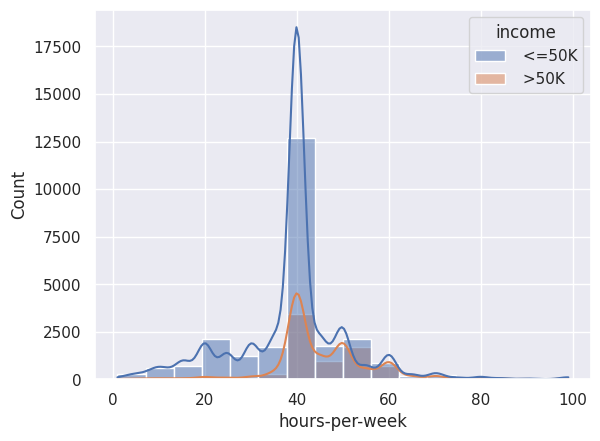

In [ ]:
sns.histplot(data=df, x='hours-per-week', hue='income', kde=True, bins='sturges');

¿Qué observamos?

## Estimaciones puntuales

En este caso el tipo de pregunta que se desea responder con el análisis es: ¿Cuál es el valor esperado de la parámetro de una variable, y con que incertidumbre o error?

Por ejemplo, ¿cual es valor esperado del promedio de horas a ala semana que trabaja una persona en Estados Unidos que gana más de $\$50.000$?

Podría pensarse que el valor esperado de la población es el mismo promedio de la muestra, pero esto **solo es cierto si la variable es normal**.

In [ ]:
print('Promedio esperado de la variable hours-per-week: ', df[df['income']==' >50K']['hours-per-week'].mean().round(2), 'años')

Promedio esperado de la variable hours-per-week:  45.47 años


La incertidumbre de este parámetro se cuantificaría mediante el **error estándar**.

De forma tradicional, el error estándar se calcula así:

\begin{equation}
SE =  \frac{\sigma_x}{\sqrt{n}}
\end{equation}

donde $\sigma_x$ es la desviación estándar de la muestra disponible y $n$ es el número de observaciones de la muestra.

In [ ]:
error = df['hours-per-week'].sem()
print('Error estándar de la variable hours-per-week: ', error.round(2), 'años')

Error estándar de la variable hours-per-week:  0.07 años


En realidad, el valor esperado de la media debería calcularse promediando las medias de muchas muestras aleatorias de la misma población. La incertidumbre sería en este caso la desviación estándar de ese conjunto de medias, concoida como el **error estándar**.

El problema es que casi nunca es posible tener muchas muestras aleatorias de una población, casi siempre tenemos solo una.



Dado que lo ideal sería tener muchas muestras, se han creado varias técnicas de remuestreo para generar múltiples meustras a partir de la muestra original. Un conjunto de técnicas muy usadas son las de *bootstrap*, que son técnicas de *remuestreo* con reemplazo.

In [ ]:
from scipy.stats import bootstrap

bs_high_income = bootstrap(data=np.array(df[df['income']==' >50K']['hours-per-week']).reshape(1,-1), n_resamples=1000, statistic=np.mean)
print('Promedio esperado de la variable hours-per-week: ', bs_high_income.bootstrap_distribution.mean().round(2), 'años')
print('Error estándar de la variable hours-per-week: ', bs_high_income.bootstrap_distribution.std().round(2), 'años')

Promedio esperado de la variable hours-per-week:  45.47 años
Error estándar de la variable hours-per-week:  0.12 años


La distribución muestral de los parámetros (la media, la mediana, la desviación estándar) de una población tiende a ser normal, así la distribución de la población no sea normal.

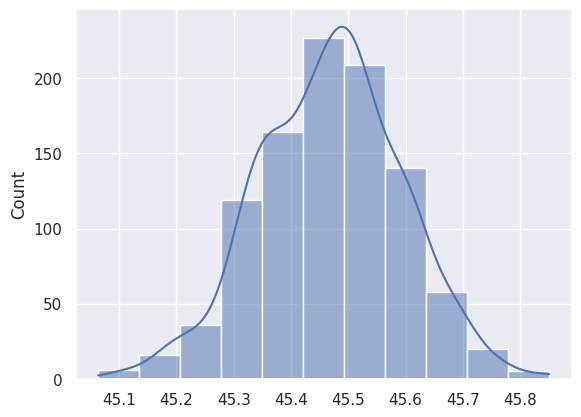

In [ ]:
sns.histplot(bs_high_income.bootstrap_distribution, kde=True, bins='sturges');

Con el método de bootstrap es posible calcular los valores esperados de otros medidas diferentes a la media. Con el método clásico no es posible.

In [ ]:
bs_high_income_median = bootstrap(data=np.array(df[df['income']==' >50K']['hours-per-week']).reshape(1,-1), n_resamples=1000, statistic=np.median)
print('Mediana esperado de la variable hours-per-week: ', bs_high_income_median.bootstrap_distribution.mean().round(2), 'años')
print('Error estándar de la mediana esperada hours-per-week: ', bs_high_income_median.bootstrap_distribution.std().round(2), 'años')

Mediana esperado de la variable hours-per-week:  40.12 años
Error estándar de la mediana esperada hours-per-week:  0.46 años


/usr/local/lib/python3.13/dist-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


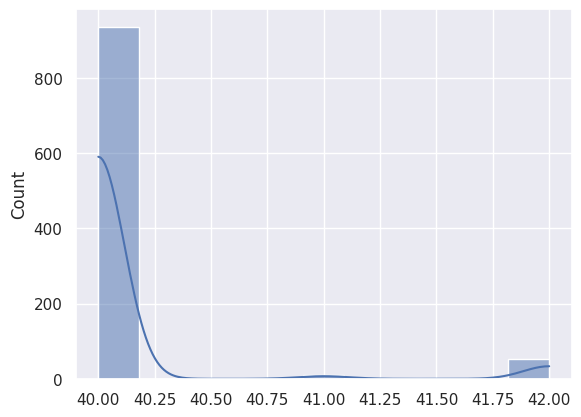

In [ ]:
sns.histplot(bs_high_income_median.bootstrap_distribution, kde=True, bins='sturges');

### Ejercicio

Calcule los valores esperados de la media y el error estándar de la variable "hours-per-week" para la población de Estados Unidos de ingreso inferior a $\$50.000$.

Use el método clásico y el método de boostrap.

Compare los resultados.

## Intervalos de confianza

La estimación puntual da un único valor plausible para un parámetro. Sin embargo, como se ha visto, esta estimación no es perfecta, y tiene algún error, que es expresado en el error estándar como medida de variabilidad.

El siguiente paso es dar un *rango de valores plausibles* para el parámetro. Este rango se llama *intervalo de confianza*.

El método clásico solo funciona para distribuciones normales de la muestra. Asumiendo que esto es cierto, el intervalo de confianza del 95% se define como:

\begin{equation}
95\% CI = [\theta - 1.96*SE, \theta + 1.96*SE]
\end{equation}

In [ ]:
min_ci, max_ci = df['hours-per-week'].agg(lambda x: [np.mean(x) - 1.96*np.std(x)/np.sqrt(len(x)),np.mean(x) + 1.96*np.std(x)/np.sqrt(len(x))])
print('Intervalo de confianza del 95% para el promedio esperado de la variable hours-per-week: [', min_ci.round(2),',', max_ci.round(2), ']')

Intervalo de confianza del 95% para el promedio esperado de la variable hours-per-week: [ 40.3 , 40.57 ]


In [ ]:
min_ci, max_ci = df[df['income']==' >50K']['hours-per-week'].agg(lambda x: [np.mean(x) - 1.96*np.std(x)/np.sqrt(len(x)),np.mean(x) + 1.96*np.std(x)/np.sqrt(len(x))])
print('Intervalo de confianza del 95% para la variable hours-per-week: [', min_ci.round(2),',', max_ci.round(2), ']')

Intervalo de confianza del 95% para la variable hours-per-week: [ 45.23 , 45.72 ]


Con bootstrap no es necesario que la distribución muestral sea normal. El $CI$ se calcularía encontrando los percentiles 2.5 y 97.5 de la distribución muestral del parámetro, aunque el método "bootstrap" de SciPy hace eso por nosotros.

In [ ]:
bs_high_income = bootstrap(data=np.array(df[df['income']==' >50K']['hours-per-week']).reshape(1,-1), n_resamples=1000, statistic=np.mean)
print('Intervalo de confianza del 95% para la media de hours-per-week: [', bs_high_income.confidence_interval[0].round(2),',', bs_high_income.confidence_interval[1].round(2), ']')

Intervalo de confianza del 95% para la media de hours-per-week: [ 45.22 , 45.7 ]


In [ ]:
bs_high_income_std = bootstrap(data=np.array(df[df['income']==' >50K']['hours-per-week']).reshape(1,-1), n_resamples=1000, statistic=np.std)
print('Intervalo de confianza del 95% para la desviación estandar de hours-per-week: [', bs_high_income_std.confidence_interval[0].round(2),',', bs_high_income_std.confidence_interval[1].round(2), ']')

Intervalo de confianza del 95% para la desviación estandar de hours-per-week: [ 10.7 , 11.29 ]


### Ejercicio

Calcule los intervalos de confianza de la media y la desviación estándar de la variable "hours-per-week" para la población de Estados Unidos de ingreso inferior a $\$50.000$.

Use el método clásico y el método de boostrap.

Compare los resultados.

**¿Cómo interpretar el intervalo de confianza?**

La interpretación del *95\% CI* no es tan evidente, y suele mal interpretarse como que existe un $95\%$ de probabilidad de que el verdadero valor de un parámetro esté en ese intervalo. La interpretación correcta es que si se repitiera muchísimas veces el muestreo aleatorio de una población, en las mismas condiciones que se hizo con la muestra que tenemos, el $95\%$ de las veces el $95\% CI$ contendría el verdadero valor del parámetro.

Para un analista de datos, el $95\% CI$ es simplemente una medida de cuan variable puede ser un resultado. No nos preocupamos mucho por la interpretación formal del $95\% CI$.

En general, si la muestra es pequeña el $95\% CI$ tenderá a ser más grande, lo que es un indicador de mayor incertidumbre sobre el resultado.